## IMPORT LIBRARIES

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

    ## Business Cost Analysis & Evaluation Metrics

    ---

    ##  Business Cost Analysis
    In Credit Card Fraud Detection, the cost of misclassification is **asymmetric**. We must prioritize avoiding the most expensive errors.

    | Error Type | Prediction | Actual | Business Impact | Cost |
    | :--- | :---: | :---: | :--- | :--- |
    | <span style="color:red">**False Negative (FN)**</span> | Normal | **Fraud** | **Leakage:** Bank loses money directly; Customer trust is damaged. | **EXTREME** |
    | <span style="color:orange">**False Positive (FP)**</span> | **Fraud** | Normal | **False Alarm:** Valid transaction blocked; Customer annoyance. | **LOW** |

    > **Strategic Conclusion:** **FN is much more dangerous than FP**. Our primary goal is to **Maximize Recall** (catch as many frauds as possible) while maintaining a reasonable Precision to avoid excessive false alarms.
    ---

    ## Key Evaluation Metrics

    Since our data is highly imbalanced (**0.17% fraud**), **Accuracy is a misleading metric**. We focus on:

    ### 1. Precision (Quality)
    $$Precision = \frac{TP}{TP + FP}$$
    * **Meaning:** Out of all transactions flagged as fraud, how many were **actually** fraud?
    * *Higher Precision = Fewer false alarms (Lower FP).*

    ### 2. Recall (Quantity / Sensitivity)
    $$Recall = \frac{TP}{TP + FN}$$
    * **Meaning:** Out of all actual fraud cases, how many did the model **capture**?
    * *Higher Recall = Fewer missed frauds (Lower FN).*

    ### 3. F1-Score (Balance)
    $$F1 = 2 \times \frac{Precision \times Recall}{Precision + Recall}$$
    * **Meaning:** The harmonic mean of Precision and Recall. It provides a single score to balance both metrics.

    ### 4. AUC-ROC
    * **Meaning:** Measures the model's ability to distinguish between classes across all thresholds.
    * **Note:** Can be over-optimistic in imbalanced datasets.

    ### 5. AUC-PR (Average Precision) -  **Primary Metric**
    * **Meaning:** Area under the Precision-Recall curve.
    * **Why chosen:** It focuses specifically on the **Minority Class (Fraud)** and is the most reliable metric for imbalanced classification tasks.

    ---

    ### Final Goal for Model Training:
    We will aim for a high **AUC-PR** and **Recall** to ensure maximum protection for the bank and its customers.

## Train 3 Models

In [2]:
X_train_under = pd.read_csv("../data/processed/X_train_under.csv")
y_train_under = pd.read_csv("../data/processed/y_train_under.csv")

y_test = pd.read_csv("../data/processed/y_test.csv")
X_test = pd.read_csv("../data/processed/X_test.csv")


X_train_smote = joblib.load("../data/processed/X_train_smote.pkl")
y_train_smote = joblib.load("../data/processed/y_train_smote.pkl")

print(f"Undersampled Shape: {X_train_under.shape}")
print(f"SMOTE Shape: {X_train_smote.shape}")

Undersampled Shape: (756, 31)
SMOTE Shape: (453204, 31)


In [ ]:
# Setup Cross-Validation
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from imblearn.pipeline import Pipeline
from sklearn.metrics import average_precision_score, f1_score



pipelines = {
    "Logistic Regression": Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', LogisticRegression(max_iter=1000, solver='lbfgs'))
    ]),
    'Random Forest' : Pipeline([
        ('model', RandomForestClassifier(n_estimators=100, random_state=42) )
    ]),
    'XGBoost' : Pipeline([
        ('model', XGBClassifier(n_estimators=100, max_depth=6, learning_rate=0.1, random_state=42, eval_metric='logloss'))
    ]),
}

results = []

sampling_methods = {
    "SMOTE": (X_train_smote, y_train_smote.values.ravel()),
    "Undersampling": (X_train_under, y_train_under.values.ravel())
}

print(f"{'Model':<20} | {'Method':<15} | {'AUC-PR':<20} | {'F1':<10}")
print("-" * 80)

for name, pipe in pipelines.items():
    for method_name, (X_train_processed, y_train_processed) in sampling_methods.items():
        from sklearn.base import clone
        model_pipe = clone(pipe)
        
        model_pipe.fit(X_train_processed, y_train_processed)
        
        y_pred = model_pipe.predict(X_test)
        y_proba = model_pipe.predict_proba(X_test)[:, 1]
        
        auc_pr = average_precision_score(y_test, y_proba)
        f1 = f1_score(y_test, y_pred)
        
        results.append({
            "Model": name,
            "Method": method_name,
            "AUC-PR": auc_pr,
            "F1": f1
        })
        
        print(f"{name:<20} | {method_name:<15} | {auc_pr:<20} | {f1:.4f}")

Model                | Method          | AUC-PR               | F1        
--------------------------------------------------------------------------------
Logistic Regression  | SMOTE           | 0.6912842416636996   | 0.2358
Logistic Regression  | Undersampling   | 0.49256746584041505  | 0.1246
Random Forest        | SMOTE           | 0.8164618906262013   | 0.8391
Random Forest        | Undersampling   | 0.6968621536710061   | 0.1407
XGBoost              | SMOTE           | 0.8037271491065167   | 0.6814
XGBoost              | Undersampling   | 0.6614510140459128   | 0.0983


## Hyperparameter Tuning

In [4]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Get the best model
best_model = max(results, key = lambda x: x['AUC-PR'])
best_model_name = best_model['Model']

best_pipe = pipelines[best_model_name]

# Create search space
search_space = {
    'model__n_estimators': [100],
    'model__max_depth': [10, None],
    'model__min_samples_split': [2, 10],
    'model__min_samples_leaf': [1, 4]
}

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearch Tuning
grid_search = GridSearchCV(
    estimator = best_pipe,      
    param_grid = search_space,      
    scoring= 'average_precision',               
    cv=skf,             
    n_jobs=-1,                 
    verbose=2                  
)

grid_search.fit(X_train_smote, y_train_smote)

Fitting 5 folds for each of 8 candidates, totalling 40 fits


GridSearchCV(cv=StratifiedKFold(n_splits=5, random_state=42, shuffle=True),
             estimator=Pipeline(steps=[('model',
                                        RandomForestClassifier(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [10, None],
                         'model__min_samples_leaf': [1, 4],
                         'model__min_samples_split': [2, 10],
                         'model__n_estimators': [100]},
             scoring='average_precision', verbose=2)

In [6]:
print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best AUC-PR (CV): {grid_search.best_score_:.4f}")

Best Parameters: {'model__max_depth': None, 'model__min_samples_leaf': 4, 'model__min_samples_split': 10, 'model__n_estimators': 100}
Best AUC-PR (CV): 1.0000


In [ ]:
y_pred_proba = grid_search.best_estimator_.predict_proba(X_test)[:,1]
print(average_precision_score(y_test, y_pred_proba))

0.8225577131071676


# 🛑 Technical Post-Mortem: Data Leakage in Imbalanced Classification

---

## 🔍 Problem Identification: The "SMOTE Trap"
During the Hyperparameter Tuning phase, a significant discrepancy was observed:
* **Cross-Validation Score (CV):** $AUC-PR = 1.0$ (Perfect score)
* **Hold-out Test Score:** $AUC-PR = 0.8$ (Performance drop)

> **Root Cause:** **Data Leakage**. By applying SMOTE to the entire dataset *before* Cross-Validation, the model "saw" synthetic information from the validation folds during training.

---

## 🛠️ Critical Analysis of the Workflow

| Phase | Current Action (Issue) | Technical Impact |
| :--- | :--- | :--- |
| **Preprocessing** | SMOTE applied to global `X_train` | **Sample Contamination:** Synthetic samples and their "parents" are split between Train/Validation folds. |
| **Tuning** | `GridSearchCV` on oversampled data | **Overfitting:** The model memorizes synthetic patterns instead of learning real-world fraud boundaries. |
| **Validation** | Evaluation on real `X_test` | **Reality Check:** The model fails to generalize because the test set contains no synthetic data. |



---

## 💡 Strategic Lesson: The "Gold Standard" Workflow

To prevent this in future AI Engineering projects, the **Resampling** must be part of the **Validation Loop**, not the Preprocessing step.

### 1. The Power of Pipelines
Instead of manual SMOTE, use `imblearn.pipeline`. It ensures that SMOTE is **only applied to the Training Fold** in each iteration, leaving the Validation Fold as pure, real-world data.

### 2. Tuning on Original Data (Recovery Strategy)
If you have already processed the data, the most reliable way to find hyperparameters is to **Tune on the Original (Imbalanced) Data**:
* **Pros:** Ensures the model parameters are optimized for real data distributions.
* **Requirement:** Must use `scoring='average_precision'` to force the model to focus on the minority class (Fraud).

## Model Evaluation


### Predicting and Calculating Metrics

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, classification_report, roc_curve, auc, 
                            precision_recall_curve, average_precision_score, roc_auc_score,
                            f1_score, precision_score, recall_score)

# Predict
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
y_proba = best_rf.predict_proba(X_test)[:, 1]

# Metric
metrics_data = {
    'Metric': ['Precision (Class 1)', 'Recall (Class 1)', 'F1-Score (Class 1)', 'AUC-ROC', 'Average Precision (AUC-PR)'],
    'Score': [
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred),
        roc_auc_score(y_test, y_proba),
        average_precision_score(y_test, y_proba)
    ]
}
metrics_df = pd.DataFrame(metrics_data)
print("--- MODEL EVALUATION INDEX TABLE ---")
print(metrics_df.to_string(index=False))

--- MODEL EVALUATION INDEX TABLE ---
                    Metric    Score
       Precision (Class 1) 0.902439
          Recall (Class 1) 0.778947
        F1-Score (Class 1) 0.836158
                   AUC-ROC 0.960899
Average Precision (AUC-PR) 0.822558


### Confusion Matri


Detailed analysis:
- Number of missed Fraud cases (False Negative): 21 (Extremely dangerous!)
- Number of falsely flagged cases (False Positive): 8 (Causes inconvenience to customers)


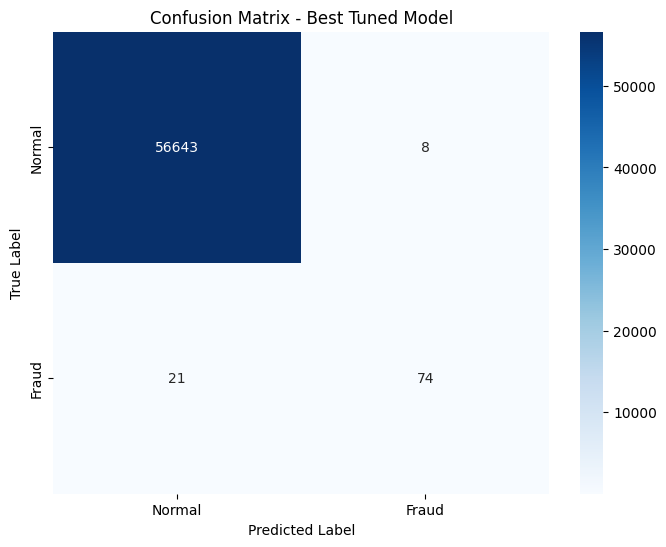

In [ ]:
cm = confusion_matrix(y_test, y_pred)
labels = ['Normal', 'Fraud']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix - Best Tuned Model')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')

tn, fp, fn, tp = cm.ravel()
print(f"\nDetailed analysis:")
print(f"- Number of missed Fraud cases (False Negative): {fn} (Extremely dangerous!)")
print(f"- Number of falsely flagged cases (False Positive): {fp} (Causes inconvenience to customers)")
plt.show()

### ROC & Precision-Recall Curve

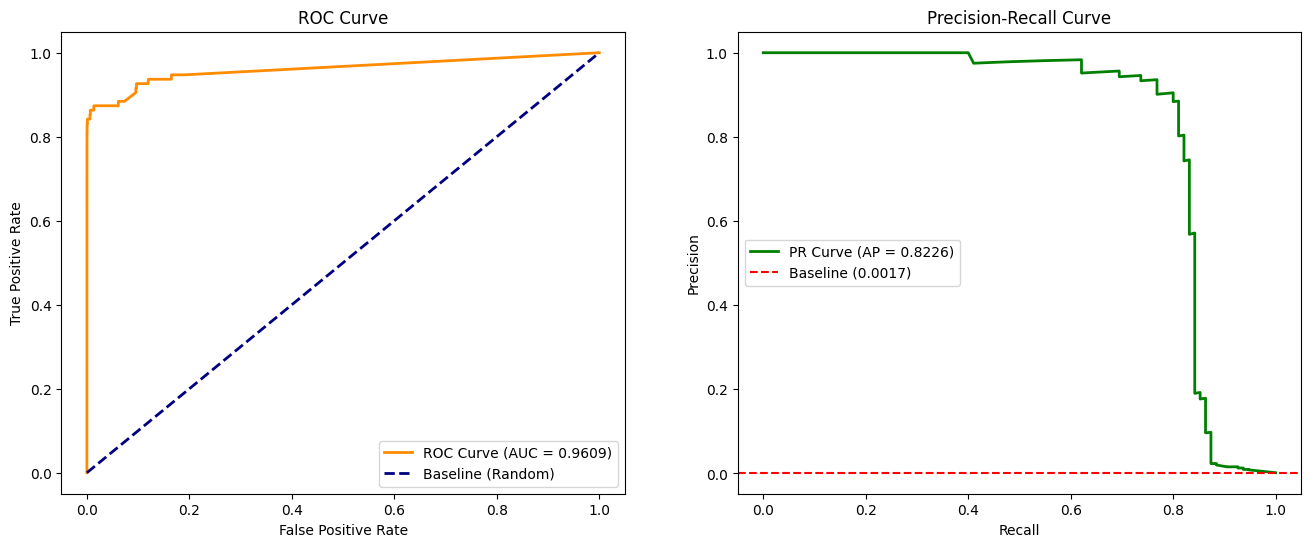

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_proba)
ax1.plot(fpr, tpr, label=f'ROC Curve (AUC = {auc(fpr, tpr):.4f})', color='darkorange', lw=2)
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Baseline (Random)')
ax1.set_title('ROC Curve')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()

# PR Curve
precision, recall, _ = precision_recall_curve(y_test, y_proba)
ap_score = average_precision_score(y_test, y_proba)
baseline_pr = y_test.mean().item()
ax2.plot(recall, precision, label=f'PR Curve (AP = {ap_score:.4f})', color='green', lw=2)
ax2.axhline(y=baseline_pr, color='red', linestyle='--', label=f'Baseline ({baseline_pr:.4f})')
ax2.set_title('Precision-Recall Curve')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.legend()

plt.show()

### Feature Importance

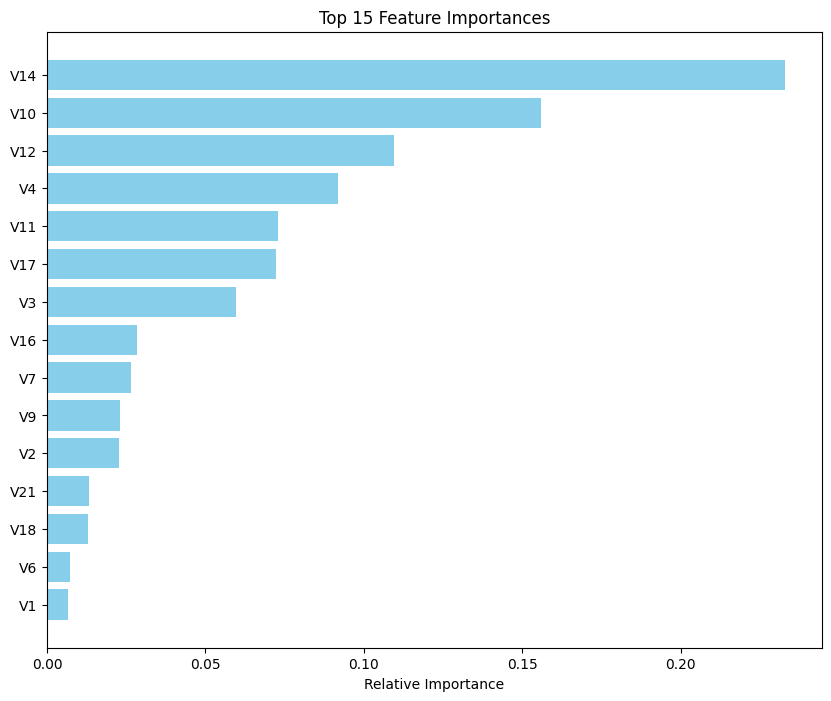

In [14]:
feature_names = X_test.columns
importances = best_rf.named_steps['model'].feature_importances_
indices = np.argsort(importances)[-15:] # Lấy top 15

plt.figure(figsize=(10, 8))
plt.title('Top 15 Feature Importances')
plt.barh(range(len(indices)), importances[indices], color='skyblue', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Relative Importance')
plt.show()

### Error Analysis

In [ ]:
# Create error analysis dataframe
error_df = X_test.copy()
error_df['Actual'] = y_test
error_df['Predicted'] = y_pred

# Get error cases
false_negatives = error_df[(error_df['Actual'] == 1) & (error_df['Predicted'] == 0)]
false_positives = error_df[(error_df['Actual'] == 0) & (error_df['Predicted'] == 1)]
true_positives = error_df[(error_df['Actual'] == 1) & (error_df['Predicted'] == 1)]

print(f"--- ERROR ANALYSIS ---")
print(f"Number of FN: {len(false_negatives)}")
print(f"Number of FPs: {len(false_positives)}")

# Compare Amounts (If you haven't scaled the Amount, or have inverted the scale)
print(f"Average Amount of Missed Fraud (FN): {false_negatives['Amount'].mean():.2f}")
print(f"Average Amount of Caught Fraud (TP): {true_positives['Amount'].mean():.2f}")


--- ERROR ANALYSIS ---
Number of FN: 21
Number of FPs: 8
Average Amount of Missed Fraud (FN): -0.33
Average Amount of Caught Fraud (TP): -0.11


# 🛡️ Credit Card Fraud Detection: Final Project Report

A project on analyzing and building a credit card fraud detection model using the **Random Forest** algorithm combined with the **SMOTE** data balancing technique.

---

## 1. Pipeline Overview

The project went through 11 rigorous processing steps:

1. **EDA:** Analyzed class imbalance (0.17% fraud) and feature correlations.
2. **Preprocessing:** Standardized data using `StandardScaler`.
3. **Resampling:** Applied **SMOTE** to augment the minority class (Fraud).
4. **Modeling:** Trained a **Random Forest Classifier**.
5. **Hyperparameter Tuning:** Used `GridSearchCV` to optimize `n_estimators`, `max_depth`.
6. **Evaluation:** Performed multi-dimensional evaluation using Confusion Matrix, ROC, and PR Curve.
7. **Error Analysis:** Investigated the root causes of model errors.

---

## 2. Key Visualizations

### Confusion Matrix

* **Results:** Correctly detected **74** fraud cases (TP), missed **21** cases (FN), falsely flagged **8** cases (FP).
* **Insight:** The model achieves very high Precision, minimizing unnecessary card blocking for legitimate users.

### Precision-Recall Curve (PR Curve)

* **AP Score:** **0.8226** (far above the baseline of 0.0017).
* **Insight:** The PR Curve shows stable model performance until Recall reaches 0.8. This is the most reliable metric for imbalanced data.

### Feature Importance

* **Top Features:** **V14** (weight > 0.23), followed by **V10**, **V12**.
* **Insight:** The model successfully captures important latent features instead of relying solely on transaction amount (`Amount`).

---

## 3. Error Analysis

Based on comparison between **Missed Fraud (FN)** and **Detected Fraud (TP)**:

| Nhóm lỗi                 | Số lượng | Average Amount (Scaled) | Đặc điểm hành vi                      |
| :----------------------- | :------- | :---------------------- | :------------------------------------ |
| **False Negatives (FN)** | 21       | **-0.33**               | Very small-value fraud (Micro-fraud). |
| **True Positives (TP)**  | 74       | **-0.11**               | Medium/large-value fraud.             |

> **Conclusion:** The current model struggles with “bleeding” transactions (very small amounts), as they closely resemble normal daily spending behavior.

---

## 4. Overall Conclusion

### Achievements

* Achieved **F1-Score 0.83**, an impressive result for a fraud detection problem.
* Clean and logical data processing pipeline with well-structured hyperparameter tuning.
* Identified the model’s “blind spots” to guide future improvements.

### Lessons Learned

* **Data Leakage:** Applying SMOTE before cross-validation is a technical mistake. In the future, `imblearn.pipeline` should be used for a more reliable process.
* **Metric Selection:** Accuracy must not be used for imbalanced datasets.

### Future Work

* Experiment with boosting models (**XGBoost/LightGBM**).
* Engineer additional **Frequency** and **Recency** features to better detect small-scale fraud.

---

*Author: Le Quang Anh Tuan
*Completion Date: 31/03/2026*


## Save Model
